# Practicum 2
## Group 23: Jing Cheng and Martina Ferrari

# Question 1 — The DS Problem (0 point)
*   In your own words, formulate the Data Science problem.

Our main goal is to use different machine learning techniques to analyze the CDC Diabetes Health Indicators dataset. We aim to build a predictive model that can accurately classify people into one of three categories: diabetic, pre-diabetic, or healthy, based on a variety of demographic, lifestyle, and health-related features. This classification will help us understand the relationship between lifestyle factors and diabetic outcomes, and perhaps identify high-risk people who could benefit from early intervention and preventive measures.

# Question 2 — Prepare the Data (5 pts)

- Evaluate the dataset to determine if ALL variables are represented in their expected type. Convert variables to suitable data types for ML modeling. This means that you need to identify categorical data, discrete and continuous variables represent them accordingly.
- Analyze the data to determine what preprocessing steps are needed to ensure that the following are handled: 1) missing values, 2) invalid values, 3) outliers. Perform the required data preparation steps and justify the approach that is taken to prepare the data for analysis. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import pearsonr, chi2_contingency

In [2]:
# Load the data
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# Inspect the dimensions and datatypes 
print('There are {} rows and {} columns.'.format(df.shape[0], df.shape[1]))
original_number_data = df.shape[0]
print()
df.info()

There are 253680 rows and 22 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth      

Based on the data dictionary, the following types are either binary types or have a certain range of levels, meaning that they should be converted to categories:
- Diabetes_012
- HighBP
- HighChol
- CholCheck
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- AnyHealthcare
- NoDocbcCost
- GenHlth
- DiffWalk
- Sex
- Age
- Education
- Income

and the remaining columns would be converted to integers.

In [4]:
# Convert to appropriate datatypes
df = df.astype(int)
df['Diabetes_012'] = df['Diabetes_012'].astype('category')
df['HighBP'] = df['HighBP'].astype('category')
df['HighChol'] = df['HighChol'].astype('category')
df['CholCheck'] = df['CholCheck'].astype('category')
df['Smoker'] = df['Smoker'].astype('category')
df['Stroke'] = df['Stroke'].astype('category')
df['HeartDiseaseorAttack'] = df['HeartDiseaseorAttack'].astype('category')
df['PhysActivity'] = df['PhysActivity'].astype('category')
df['Fruits'] = df['Fruits'].astype('category')
df['Veggies'] = df['Veggies'].astype('category')
df['HvyAlcoholConsump'] = df['HvyAlcoholConsump'].astype('category')
df['AnyHealthcare'] = df['AnyHealthcare'].astype('category')
df['NoDocbcCost'] = df['NoDocbcCost'].astype('category')
df['GenHlth'] = df['GenHlth'].astype('category')
df['DiffWalk'] = df['DiffWalk'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Age'] = df['Age'].astype('category')
df['Education'] = df['Education'].astype('category')
df['Income'] = df['Income'].astype('category')

In [5]:
# make sure the datatypes are updated
df.dtypes

Diabetes_012            category
HighBP                  category
HighChol                category
CholCheck               category
BMI                        int64
Smoker                  category
Stroke                  category
HeartDiseaseorAttack    category
PhysActivity            category
Fruits                  category
Veggies                 category
HvyAlcoholConsump       category
AnyHealthcare           category
NoDocbcCost             category
GenHlth                 category
MentHlth                   int64
PhysHlth                   int64
DiffWalk                category
Sex                     category
Age                     category
Education               category
Income                  category
dtype: object

In [6]:
# Checks the frequency of missing data in each column
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

This means that there no missing data that we need to handle.

In [7]:
# Check for invalid data
df.describe(include='all')

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.0,253680.0,253680.0,253680.000000,253680.0,253680.0,253680.0,253680.0,253680.0,...,253680.0,253680.0,253680.0,253680.000000,253680.000000,253680.0,253680.0,253680.0,253680.0,253680.0
unique,3.0,2.0,2.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,5.0,NaN,NaN,2.0,2.0,13.0,6.0,8.0
top,0.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,NaN,NaN,0.0,0.0,9.0,6.0,8.0
freq,213703.0,144851.0,146089.0,244210.0,NaN,141257.0,243388.0,229787.0,191920.0,160898.0,...,241263.0,232326.0,89084.0,NaN,NaN,211005.0,141974.0,33244.0,107325.0,90385.0
mean,NaN,NaN,NaN,NaN,28.382364,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.184772,4.242081,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,6.608694,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.412847,8.717951,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,NaN,NaN,NaN


In [8]:
# Checks the statistics for the hidden columns
df[['Veggies', 'HvyAlcoholConsump']].describe()

,Veggies,HvyAlcoholConsump
count,253680,253680
unique,2,2
top,1,0
freq,205841,239424


Based on the describe function, the categorical and numerical features all seemed pretty reasonable as they are within the the range given by the data dictionary except for the two numerical features, MentHlth and PhysHlth.There are more than 50% values of zero, which is invalid, in our numerical columns so we can't use deletion in this case. Based on the statistics, the data is highly skewed and the median is zero in both columns. This means that we can't impute the median but we can impute the value that is closest to the median.

In [9]:
# Impute zero with the value closest to the median for the column MentHlth
filtered_data = df['MentHlth'].loc[df['MentHlth'] != df['MentHlth'].median()]
closest_value = filtered_data.iloc[(filtered_data - df['MentHlth'].median()).abs().argsort()].iloc[0]
df.loc[df['MentHlth']==0, 'MentHlth'] = closest_value

In [10]:
# Impute zero with the value closest to the median for the column PhysHlth
filtered_data = df['PhysHlth'].loc[df['PhysHlth'] != df['PhysHlth'].median()]
closest_value = filtered_data.iloc[(filtered_data - df['PhysHlth'].median()).abs().argsort()].iloc[0]
df.loc[df['PhysHlth']==0, 'PhysHlth'] = closest_value

In [11]:
# Check updated statistics
df.describe(include='all')

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.0,253680.0,253680.0,253680.000000,253680.0,253680.0,253680.0,253680.0,253680.0,...,253680.0,253680.0,253680.0,253680.000000,253680.000000,253680.0,253680.0,253680.0,253680.0,253680.0
unique,3.0,2.0,2.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,5.0,NaN,NaN,2.0,2.0,13.0,6.0,8.0
top,0.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,NaN,NaN,0.0,0.0,9.0,6.0,8.0
freq,213703.0,144851.0,146089.0,244210.0,NaN,141257.0,243388.0,229787.0,191920.0,160898.0,...,241263.0,232326.0,89084.0,NaN,NaN,211005.0,141974.0,33244.0,107325.0,90385.0
mean,NaN,NaN,NaN,NaN,28.382364,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.877298,4.873001,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,6.608694,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.124053,8.419185,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,NaN,NaN,NaN


In terms of outliers, there are three numerical columns that we have to handle: BMI, MentHlth, and PhysHlth. For the BMI column, my approach is to simply removing the outliers since the data in this column is more normally distributed compared to the other two. For the MentHlth and PhysHlth column, I chose to use the Winsorize method since there are a lot of outliers in these two columns and deleting them can hurt our model. The Winsorize method replaces the outliers with a value that doesn't exceed our upper or lower limits. 

In [12]:
# Given a dataframe and column, removes the outliers in that column 
# using the IQR approach
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR)))
    df = df[~outliers]
    return df

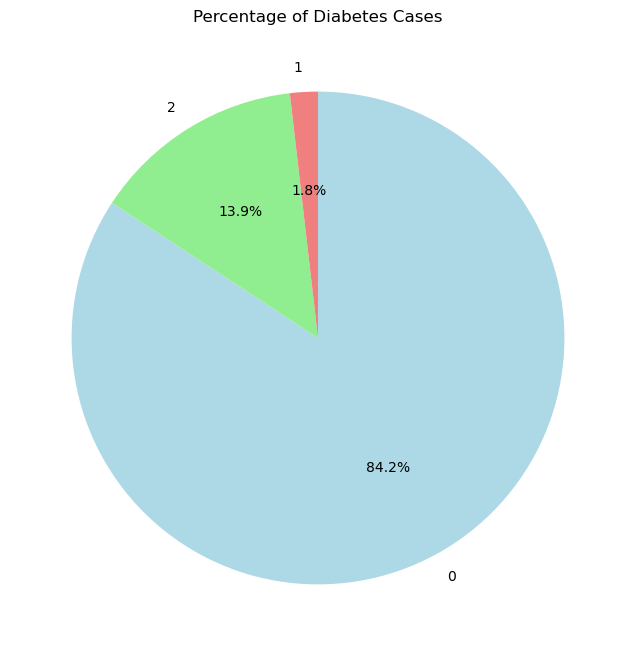

In [13]:
# Count the number of diabetes case and convert to percent
diabetes_counts = df['Diabetes_012'].value_counts()
diabetes_percentages = (diabetes_counts / diabetes_counts.sum()) * 100

# Plot the pie chart
plt.figure(figsize=(8, 8))
diabetes_percentages.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral'], 
                          startangle=90, counterclock=False)
plt.title('Percentage of Diabetes Cases')
plt.ylabel('')
plt.show()

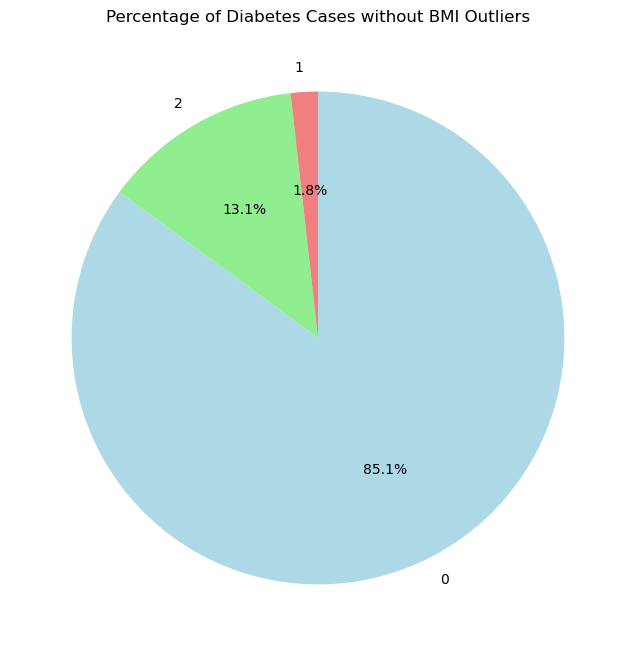

In [14]:
# Create a new dataframe with the BMI outliers removed
no_bmi_outliers = remove_outliers(df, 'BMI')

# Count the number of diabetes case and convert to percent
diabetes_counts = no_bmi_outliers['Diabetes_012'].value_counts()
diabetes_percentages = (diabetes_counts / diabetes_counts.sum()) * 100

# Plot the pie chart
plt.figure(figsize=(8, 8))
diabetes_percentages.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral'], 
                          startangle=90, counterclock=False)
plt.title('Percentage of Diabetes Cases without BMI Outliers')
plt.ylabel('')
plt.show()

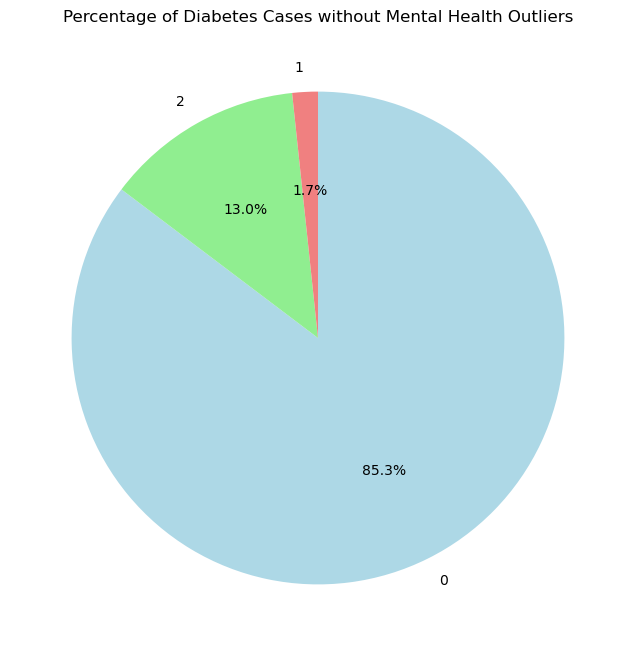

In [15]:
# Create a new dataframe with the MentHlth outliers removed
no_menthlth_outliers = remove_outliers(df, 'MentHlth')

# Count the number of diabetes case and convert to percent
diabetes_counts = no_menthlth_outliers['Diabetes_012'].value_counts()
diabetes_percentages = (diabetes_counts / diabetes_counts.sum()) * 100

# Plot the pie chart
plt.figure(figsize=(8, 8))
diabetes_percentages.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral'], 
                          startangle=90, counterclock=False)
plt.title('Percentage of Diabetes Cases without Mental Health Outliers')
plt.ylabel('')
plt.show()

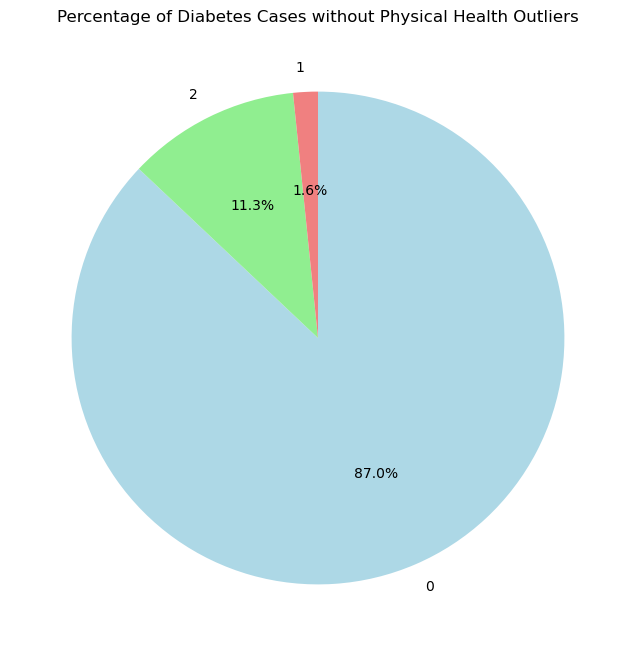

In [16]:
# Create a new dataframe with the PhysHlth outliers removed
no_physhlth_outliers = remove_outliers(df, 'PhysHlth')

# Count the number of diabetes case and convert to percent
diabetes_counts = no_physhlth_outliers['Diabetes_012'].value_counts()
diabetes_percentages = (diabetes_counts / diabetes_counts.sum()) * 100

# Plot the pie chart
plt.figure(figsize=(8, 8))
diabetes_percentages.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'lightcoral'], 
                          startangle=90, counterclock=False)
plt.title('Percentage of Diabetes Cases without Physical Health Outliers')
plt.ylabel('')
plt.show()

After comparing the distribution of the diabetic status with the the distribution of the diabete status in which the outliers are removed, there is not much difference between the distribution. Thus, we do not need to remove the outliers since it can be due to natural variations.

In [17]:
# Removes the outliers in the BMI column
#df = remove_outliers(df, 'BMI')

In [18]:
df.describe(include='all')

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.0,253680.0,253680.0,253680.000000,253680.0,253680.0,253680.0,253680.0,253680.0,...,253680.0,253680.0,253680.0,253680.000000,253680.000000,253680.0,253680.0,253680.0,253680.0,253680.0
unique,3.0,2.0,2.0,2.0,NaN,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,5.0,NaN,NaN,2.0,2.0,13.0,6.0,8.0
top,0.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,NaN,NaN,0.0,0.0,9.0,6.0,8.0
freq,213703.0,144851.0,146089.0,244210.0,NaN,141257.0,243388.0,229787.0,191920.0,160898.0,...,241263.0,232326.0,89084.0,NaN,NaN,211005.0,141974.0,33244.0,107325.0,90385.0
mean,NaN,NaN,NaN,NaN,28.382364,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.877298,4.873001,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,6.608694,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.124053,8.419185,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.000000,3.000000,NaN,NaN,NaN,NaN,NaN


# Question 3 — (35 pts)
*  Perform exploratory data analysis. Ensure that you analyze the relationships between the various features and social determinants of health in the dataset, and the diabetic outcomes. Create visualizations to demonstrate your findings and explain the results.

We will begin by visualizing the distribution of the target variable Diabetes_012, which helps identify patterns and correlations within the data. We will first examine the distribution of values in this target variable.

In [19]:
df['Diabetes_012'].value_counts()

Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64

Based on this output, we can see that the majority of the values are 0, indicating no diabetes, while a smaller proportion are 1, indicating prediabetes and 2 indicating diabetes. To illustrate this distribution, we will create a count plot and adjust its scale to clearly portray the counts.

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/336811741.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diabetes_012', data=df, palette='viridis')


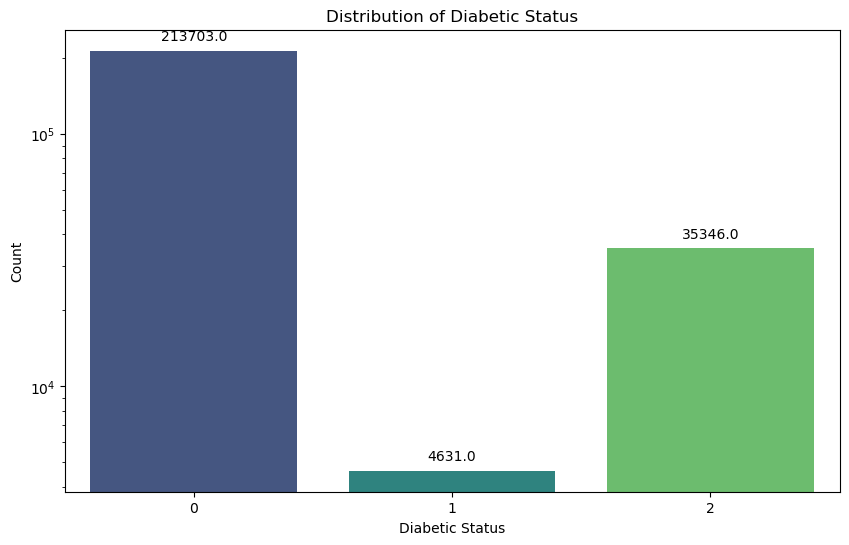

In [20]:
# Set up the count plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Diabetes_012', data=df, palette='viridis')

# Annotate the bars with counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Add title and labels
plt.title('Distribution of Diabetic Status')
plt.xlabel('Diabetic Status')
plt.ylabel('Count')
plt.yscale('log')  # Using a log scale to better visualize small counts

plt.show()

Next we will look at the distribution of continuous variables: BMI, MentHlth, and PhysHlth

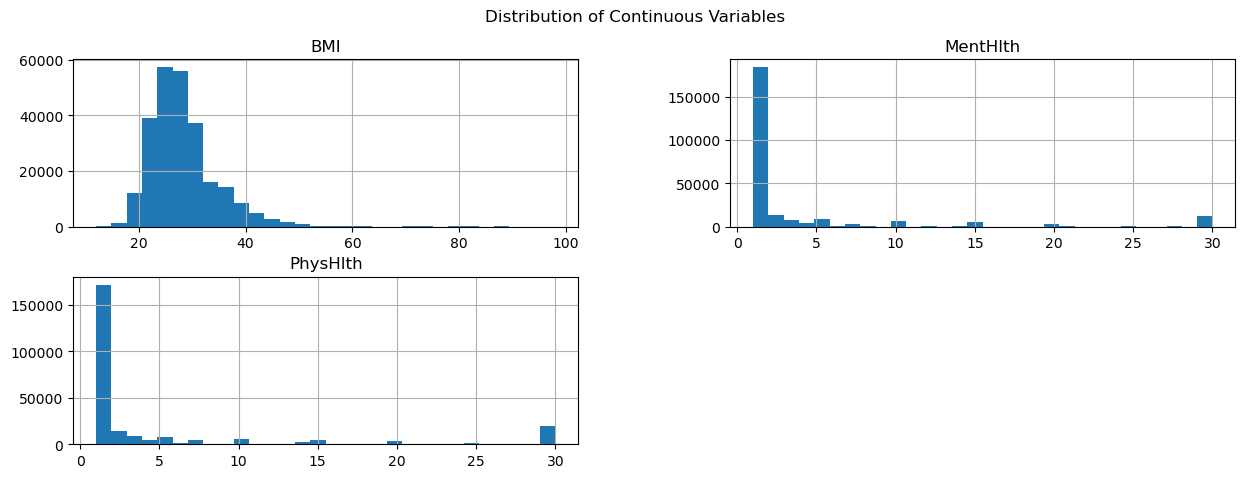

In [21]:
# Plot the distribution of continuous variables
continuous_vars = ['BMI', 'MentHlth', 'PhysHlth']
df[continuous_vars].hist(bins=30, figsize=(15, 5))
plt.suptitle('Distribution of Continuous Variables')
plt.show()

- BMI Distribution:
The BMI graph appears to have a roughly normal distribution, centered around a typical BMI range.
- Mental Health (MentHlth) Distribution:
The MentHlth graph shows a high concentration of counts at the lower end, indicating that most individuals report few to no days of poor mental health. The distribution is skewed with a long tail, indicating that a smaller number of individuals experience a higher number of days with poor mental health.
- Physical Health (PhysHlth) Distribution:
Similar to MentHlth, the PhysHlth graph has a high concentration of counts at the lower end, suggesting that most individuals report few to no days of poor physical health. This distribution is also skewed with a long tail, showing that a smaller proportion of individuals experience a higher number of days with poor physical health.

We can further explore how these continuous variables relate to the diabetic status by creating box plots.

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/1498870203.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y=var, data=df, palette='viridis')
/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/1498870203.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y=var, data=df, palette='viridis')
/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/1498870203.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y=var, data=df, palette='viridis')


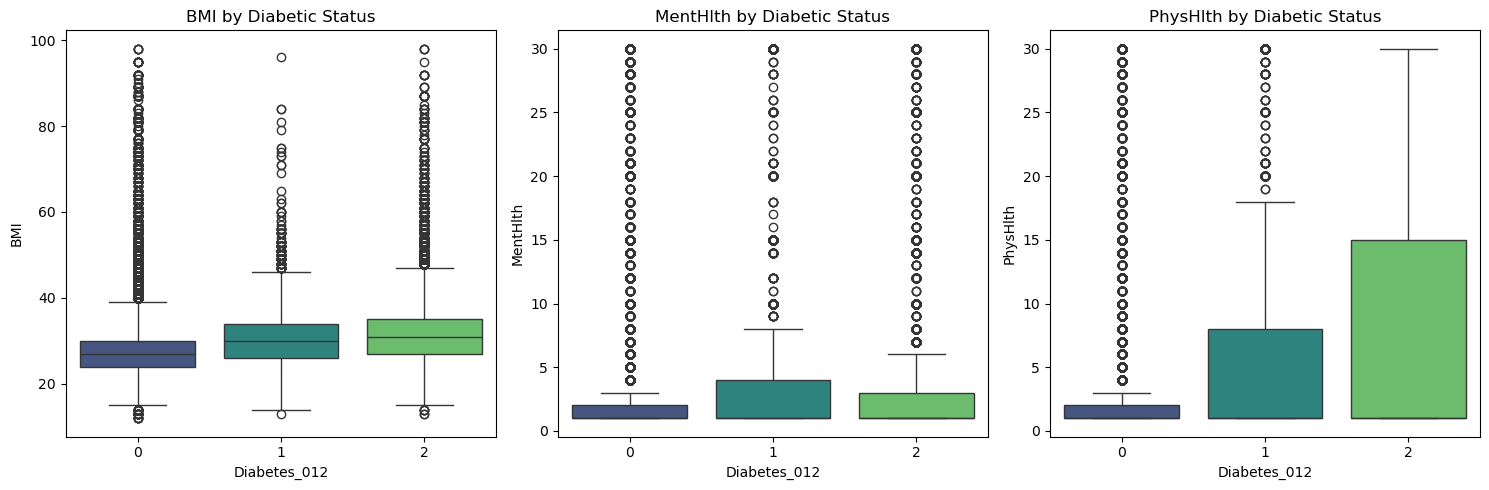

In [22]:
# Create box plots for continuous variables against the diabetic target variable
plt.figure(figsize=(15, 5))
for i, var in enumerate(continuous_vars, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Diabetes_012', y=var, data=df, palette='viridis')
    plt.title(f'{var} by Diabetic Status')
plt.tight_layout()
plt.show()

https://stackoverflow.com/questions/41667397/interactive-boxplot-with-pandas-and-jupyter-notebook

BMI by Diabetic Status: This boxplot shows the distribution of BMI among individuals categorized by their diabetic status. The highest mean BMI is seen in the group labeled '2', which represents individuals with diabetes. This indicates that people with diabetes tend to have a higher BMI, around 30. Some outliers are present, as indicated by black dots, suggesting that there are individuals with diabetes who have BMIs significantly different from the rest of the group.

Mental Health by Diabetic Status: This boxplot illustrates the distribution of mental health, measured by the number of days in the past 30 days when mental health was not good, across different diabetic statuses. The highest means are seen in groups '1' (prediabetic) and '2' (diabetic), whereas the lowest mean, around 2 days, is observed in the group with no diabetes. This suggests that individuals with more days of poor mental health are more likely to be prediabetic or diabetic.

Physical Health by Diabetic Status: Similar to the mental health boxplot, this one shows the distribution of physical health, measured by the number of days in the past 30 days when physical health was not good. Groups '1' (prediabetic) and '2' (diabetic) show higher means, indicating more days of poor physical health compared to the non-diabetic group, which has a mean of 2 days. Some outliers are present in the non-diabetic group, showing individuals with atypically high numbers of poor physical health days.

For categorical variables, we can use bar plots to examine the distribution of diabetic status within each category. We can start with some categorical variables like HighChol, PhysActivity, HvyAlcoholConsump, and Age.

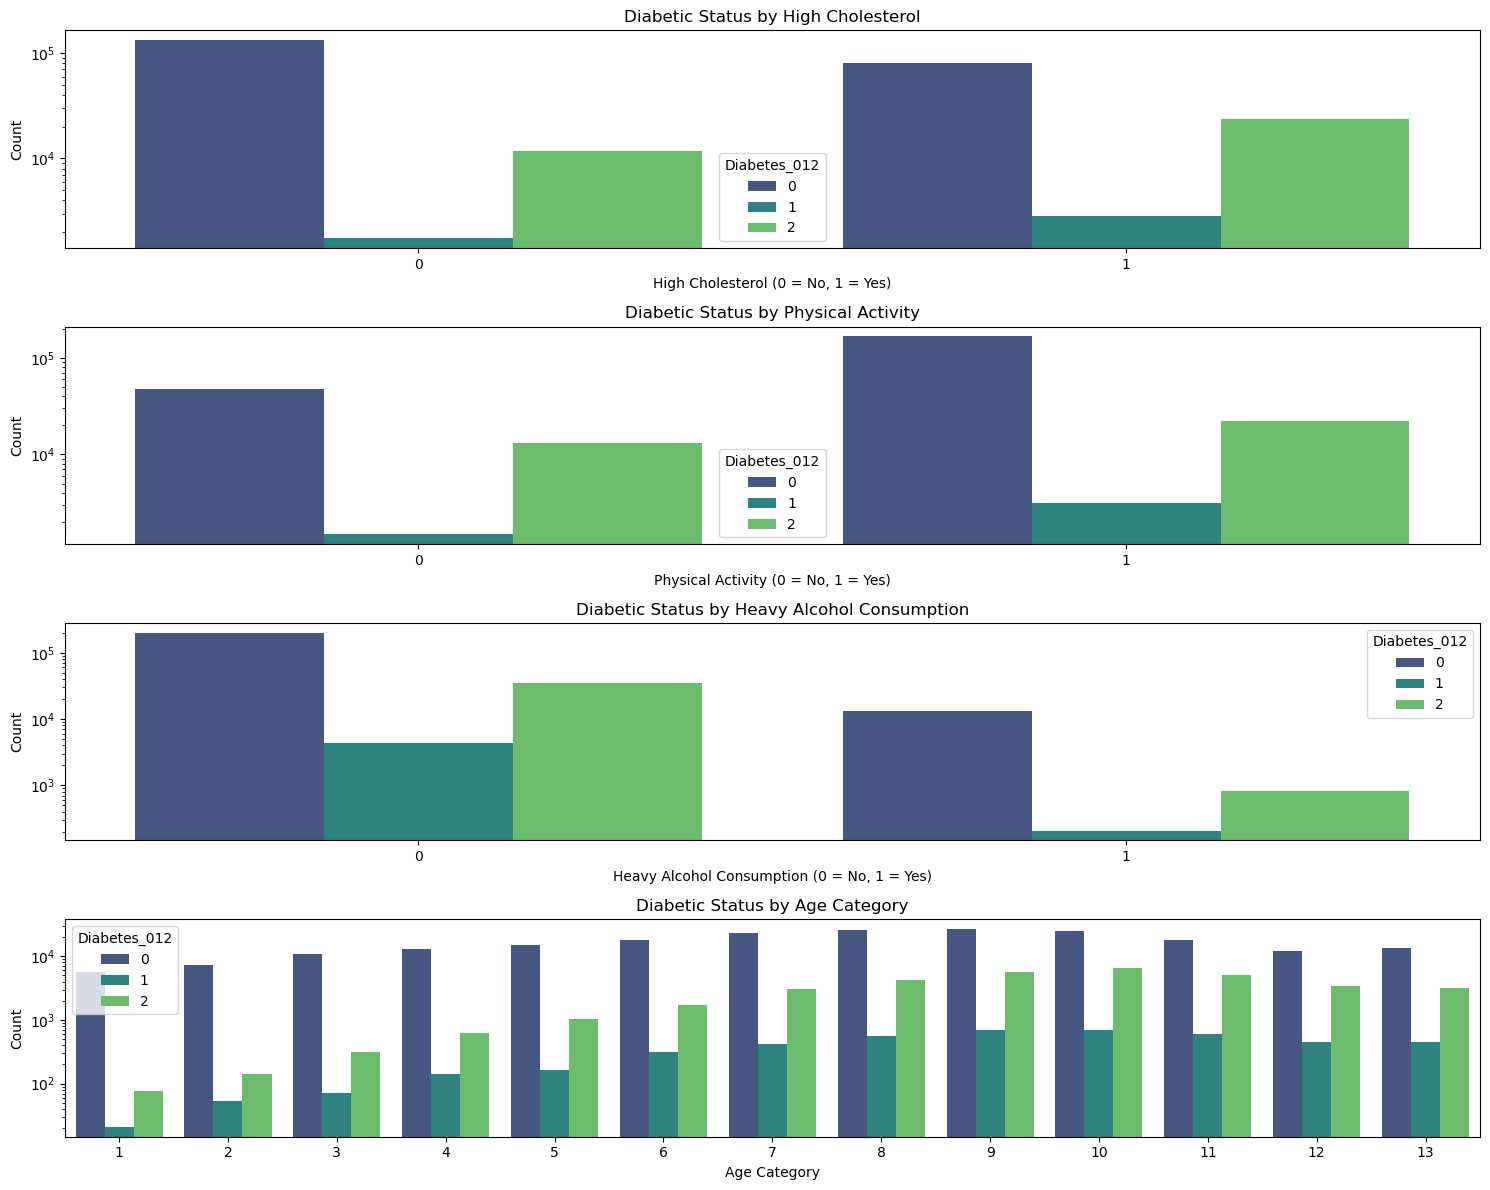

In [23]:
# Define the categorical variables to plot
categorical_vars = ['HighChol', 'PhysActivity', 'HvyAlcoholConsump', 'Age']

# Plot the distribution of diabetic status within each categorical variable
plt.figure(figsize=(15, 12))
for i, var in enumerate(categorical_vars, 1):
    plt.subplot(len(categorical_vars), 1, i)
    sns.countplot(x=var, hue='Diabetes_012', data=df, palette='viridis')

    # Add title and labels based on the variable
    if var == 'HighChol':
        plt.title('Diabetic Status by High Cholesterol')
        plt.xlabel('High Cholesterol (0 = No, 1 = Yes)')
    elif var == 'PhysActivity':
        plt.title('Diabetic Status by Physical Activity')
        plt.xlabel('Physical Activity (0 = No, 1 = Yes)')
    elif var == 'HvyAlcoholConsump':
        plt.title('Diabetic Status by Heavy Alcohol Consumption')
        plt.xlabel('Heavy Alcohol Consumption (0 = No, 1 = Yes)')
    elif var == 'Age':
        plt.title('Diabetic Status by Age Category')
        plt.xlabel('Age Category')
    else:
        plt.title(f'Diabetic Status by {var}')
        plt.xlabel(var)

    plt.ylabel('Count')
    plt.yscale('log')  # Using a log scale to better visualize small counts

plt.tight_layout()
plt.show()

https://www.geeksforgeeks.org/countplot-using-seaborn-in-python/

These bar plots show how the diabetic status varies across different categories for each variable.

These bar plots show how the diabetic status varies across different categories for each variable.

1. Diabetic  Status by HighChol: For those without high cholesterol (category 0), the majority do not have diabetes, although a small proportion does. Conversely, among individuals with high cholesterol (category 1), while most do not have diabetes, there is a comparatively larger proportion who are diabetic. This pattern suggests a potential association between high cholesterol levels and an increased likelihood of diabetes.

2. Diabetic Status by Physical Activity: Surprisingly, this graph reveals that individuals who reported engaging in physical activity in the past 30 days (category 1) have a higher proportion of diabetes compared to those who did not (category 0). However, it's notable that a larger proportion of physically active individuals do not have diabetes. This complex relationship might indicate that while physical activity is generally beneficial, other factors could influence diabetes risk among active individuals.

3. Diabetic Status by Heavy Alcohol Consumption: Despite the majority of individuals in the dataset not reporting heavy alcohol consumption, there appears to be a higher proportion of diabetic individuals among those who do not heavily consume alcohol compared to those who do. This suggests that there may not be a proportional relationship between heavy alcohol consumption and diabetes risk within this dataset.

4. Diabetic Status by Age Category: As age increases, there is a noticeable upward trend in the proportion of individuals with diabetes. This observation aligns with the understanding that as we get older there is ahigher risk of diabetes.

# Question 4a — (20 points)
Perform significance tests to determine if the patterns that are detected above are statistically significant. Ensure that you discuss at least three patterns and the respective p-values.
Select the features that will be used in the ML models (i.e. your selected features should be based on analytical reasoning that demonstrates their utility for ML modeling. Do not arbitrarily select features.
Note: if you are using correlations, ensure that this is only performed using continuous variables.

In [24]:
# Selecting columns
continuous_cols = ['BMI']
categorical_cols = ['Age', 'HighChol', 'PhysActivity', 'HvyAlcoholConsump']

# Calculate correlation coefficients and p-values for continuous variables
correlation_values = []
p_values = []

for col in continuous_cols:
    corr, p_val = pearsonr(df[col], df['Diabetes_012'])
    correlation_values.append(round(corr, 2))
    p_values.append(round(p_val, 2))

# Create a dataframe to store results for continuous variables
continuous_results_df = pd.DataFrame({'Variable': continuous_cols, 'Correlation_with_Diabetes_012': correlation_values, 'P-value': p_values})

# Perform Chi-Square test for categorical variables
chi2_values = []
p_values_chi2 = []

for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Diabetes_012'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    chi2_values.append(round(chi2, 2))
    p_values_chi2.append(round(p, 2))

# Create a dataframe to store results for categorical variables
categorical_results_df = pd.DataFrame({'Variable': categorical_cols, 'Chi2_Value': chi2_values, 'P-value': p_values_chi2})

# Display results
print("Continuous Variables:")
print(continuous_results_df)
print("\nCategorical Variables:")
print(categorical_results_df)

Continuous Variables:
  Variable  Correlation_with_Diabetes_012  P-value
0      BMI                           0.22      0.0

Categorical Variables:
            Variable  Chi2_Value  P-value
0                Age     9641.38      0.0
1           HighChol    11258.92      0.0
2       PhysActivity     3789.30      0.0
3  HvyAlcoholConsump      850.32      0.0


1. BMI (Continuous):
- Correlation: 0.22
- P-value: 0
- The correlation between BMI and the likelihood of having diabetes is approximately 0.22, indicating a positive correlation. This suggests that as BMI increases, the probability of having diabetes also tends to increase. The p-value of 0.0 (rounded) indicates a very strong statistical significance, meaning that this observed correlation is highly unlikely to be due to random chance. Therefore, BMI is an important feature to include in the model for predicting diabetes risk.

2. Age (Categorical):
- Chi-Square Value: 9641.38
- P-value: 0.0
- The Chi-Square test indicates a significant association between age categories and the likelihood of having diabetes. This suggests that as age increases, the likelihood of having diabetes also tends to increase. The extremely small p-value (rounded to 0.0) confirms strong statistical significance, indicating that age is an important predictor in the analysis.

3. HighChol (Binary):
- Chi-Square Value: 11258.92
- P-value: 0.0
- The Chi-Square test shows a significant association between high cholesterol levels and diabetes. Individuals with higher cholesterol levels are more likely to have diabetes. The p-value of 0.0 (rounded) indicates strong statistical significance, suggesting that this association is unlikely to be due to chance. High cholesterol is a critical feature to consider in the diabetes risk model.

4. PhysActivity (Binary):
- Chi-Square Value: 3789.30
- P-value: 0.0
- The Chi-Square test reveals a significant association between physical activity levels and diabetes. Higher levels of physical activity are associated with a lower likelihood of having diabetes. The very small p-value (rounded to 0.0) indicates strong statistical significance, suggesting that this association is unlikely to be due to random variation. Physical activity is an important factor to include in the model, indicating its protective effect against diabetes.

5. HvyAlcoholConsump (Binary):
- Chi-Square Value: 850.32
- P-value: 0.0
- The Chi-Square test indicates a significant association between heavy alcohol consumption and diabetes. Despite a weak negative correlation, the association suggests that heavy alcohol consumption might influence diabetes risk. The p-value of 0.0 (rounded) indicates strong statistical significance, suggesting that this association is unlikely to be due to random chance. Heavy alcohol consumption should be considered in the model, potentially as a confounding factor.

All features tested (BMI, Age, HighChol, PhysActivity, and HvyAlcoholConsump) show statistically significant associations with the likelihood of having diabetes, as indicated by their very low p-values (rounded to 0.0) and significant Chi-Square values. These results reinforce that each of these features is an important predictor of diabetes risk and should be included in the machine learning modeling process to improve the accuracy and effectiveness of the predictions. The strong statistical significance across all variables indicates that these associations are robust and meaningful, rather than occurring by chance.

## [Optional] Question 4b — (10 points)
This is an optional challenge question. Its purpose is to identify new features that can be included in the ML modeling below.

Perform ONE of the following
- (1) Feature engineering: Machine learning models can benefit greatly from feature engineering. Create a new feature that can be included in the model and perform significance testing to determine if it's statistically significant. Explain the results. If you decide that you will not include the new feature in the ML modeling, explain the reasons.

OR

- (2) Statistical tests: Research a new type of statistical test that was not introduced in the lecture and write python code to demonstrate at least two significance tests between features in the dataset. Explain the results. If you decide that you will not include the new feature in the ML modeling, explain the reasons. Note: you are welcome to use libraries to perform the tests.

We chose to do 2: Statistical tests --> Mann-Whitney U
The Mann-Whitney U test is a non-parametric test used to compare differences between two independent groups when the dependent variable is either ordinal or continuous but not normally distributed. It is an alternative to the t-test when the data does not meet the t-test's assumptions.

In [25]:
# Select features
features = ['BMI', 'Age', 'HighChol', 'PhysActivity', 'HvyAlcoholConsump']

# Perform Mann-Whitney U test for each numeric feature against Diabetes_012
results = {}
for feature in features:
    stat, p_value = mannwhitneyu(df[feature][df['Diabetes_012'] == 0], df[feature][df['Diabetes_012'] == 1])
    results[feature] = {'statistic': round(stat, 2), 'p_value': round(p_value, 2)}

# Print the results
for feature, result in results.items():
    print(f"Feature: {feature}")
    print(f"Mann-Whitney U Statistic: {result['statistic']}")
    print(f"P-value: {result['p_value']}")
    if result['p_value'] < 0.05:
        print("Result is statistically significant.")
    else:
        print("Result is not statistically significant.")
    print()

Feature: BMI
Mann-Whitney U Statistic: 351245390.0
P-value: 0.0
Result is statistically significant.

Feature: Age
Mann-Whitney U Statistic: 375516743.0
P-value: 0.0
Result is statistically significant.

Feature: HighChol
Mann-Whitney U Statistic: 375256199.0
P-value: 0.0
Result is statistically significant.

Feature: PhysActivity
Mann-Whitney U Statistic: 544611794.0
P-value: 0.0
Result is statistically significant.

Feature: HvyAlcoholConsump
Mann-Whitney U Statistic: 503205832.5
P-value: 0.0
Result is statistically significant.



https://www.reneshbedre.com/blog/mann-whitney-u-test.html

1. BMI
- Mann-Whitney U Statistic: 351,245,390.0
- P-value: 0.0
- Result: Statistically Significant
- This test indicates a highly statistically significant difference in BMI between individuals with and without diabetes. The extremely low p-value (0.0) suggests that the observed difference in BMI values for these two groups is highly unlikely to have occurred by random chance alone. This strong statistical significance indicates that BMI is likely a crucial factor associated with diabetes risk in our dataset.

2. Age
- Mann-Whitney U Statistic: 375,516,743.0
- P-value: 0.0
- Result: Statistically Significant
- The test shows a significant difference in age distribution between individuals with and without diabetes. With a very low p-value (0.0), this result suggests that age significantly influences the likelihood of having diabetes. As age increases, the risk of diabetes also tends to increase, making age an important predictor in our analysis.

3. HighChol
- Mann-Whitney U Statistic: 375,256,199.0
- P-value: 0.0
- Result: Statistically Significant
- The test indicates a statistically significant difference in cholesterol levels between individuals with and without diabetes. The extremely low p-value (0.0) suggests that higher cholesterol levels are associated with diabetes. This strong statistical significance implies that high cholesterol is an important factor related to diabetes risk in our dataset.

4. PhysActivity
- Mann-Whitney U Statistic: 544,611,794.0
- P-value: 0.0
- Result: Statistically Significant
- The test shows a statistically significant difference in physical activity levels between individuals with and without diabetes. The extremely low p-value (0.0) suggests that higher physical activity is associated with lower rates of diabetes. This strong statistical significance reinforces the importance of physical activity as a protective factor against diabetes.

5. HvyAlcoholConsump
- Mann-Whitney U Statistic: 503,205,832.5
- P-value: 0.0
- Result: Statistically Significant
- The test indicates a statistically significant difference in heavy alcohol consumption between individuals with and without diabetes. The very low p-value (0.0) suggests that heavy alcohol consumption might slightly affect diabetes risk. Although the effect is weak, the strong statistical significance indicates that this factor should still be considered in the analysis.

All features tested (BMI, Age, HighChol, PhysActivity, and HvyAlcoholConsump) show statistically significant differences between individuals with and without diabetes, as indicated by their very low p-values (0.0). These results suggest that each of these features is an important predictor of diabetes risk and should be included in the machine learning modeling process to improve the accuracy and effectiveness of the predictions. The strong statistical significance across all variables indicates that these differences are robust and meaningful, rather than occurring by chance.

## Question 5 — (5 points)
Partition the data into train/test sets. After which, perform the following:
- encode any categorical data. Ensure that categorical variables are represented correctly.
- normalize numeric data. Tip: Ensure that you use sklearn to normalize and/or encode the training data, after which transform the test set (there is an example in the lecture).

In [26]:
# Separate features and target variable
selected_features = ['BMI', 'HighChol', 'PhysActivity', 'HvyAlcoholConsump', 'Age']
X = df[selected_features]
y = df['Diabetes_012']

# Split data into training and testing sets
X_train, X_test, y_train, y_test, df_train, df_test = \
train_test_split(X, y, df, test_size=0.3, random_state=7, stratify=y)

In [27]:
# Identify numeric and categorical columns
numeric_features = ['BMI']
categorical_features = ['HighChol', 'PhysActivity', 'HvyAlcoholConsump', 'Age']

# Create preprocessing pipelines for both numeric and categorical data
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(drop='first'))])

In [28]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing to the training data (fit and transform)
X_train_processed = preprocessor.fit_transform(X_train)
# Apply preprocessing to the test data (transform only)
X_test_processed = preprocessor.transform(X_test)

# Question 6 — (30 points)

Build the ML model that predicts the target variable based on the selected features. Ensure that you:
- Demonstrate the training, evaluation and tuning for at least three algorithms that can handle non linear data and multiple input features/variables. NOTE: you can only select one tree-based algorithm and you must select multiple input features for the ML modeling.
- Use GridSearchCV to tune at least two hyperparameters for each algorithm.
- Note: do not change the input features in your experiments.

The three ML models we are going to use here are Logistic Regression, Decision Tree Classifier, and the k-NN Classifier.

In [29]:
# Initialize the Logistic Regression model
lr = LogisticRegression(multi_class='multinomial', solver='sag', random_state=7)

In [30]:
# Train the default model 
lr.fit(X_train_processed, y_train)

# Evaluate the accuracy of the default model 
print('The accuracy of the model is: {}'.format(round(lr.score(X_test_processed, y_test), 2)))

The accuracy of the model is: 0.84


/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [31]:
# Perform Grid Search to find the best parameters for Logistic Regression
param_grid_lr = {'C': [0.1, 1, 10, 100, 1000],
                 'max_iter': [2000, 4000, 6000, 8000]}

grid_search_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=3, 
                              scoring='accuracy', return_train_score=True, n_jobs=-1)

# Fit the data
grid_search_lr.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=LogisticRegression(multi_class='multinomial',
                                          random_state=7, solver='sag'),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'max_iter': [2000, 4000, 6000, 8000]},
             return_train_score=True, scoring='accuracy')

In [32]:
# Initialize the Decision Tree Classifier
dt = DecisionTreeClassifier(criterion='entropy', random_state=7)

In [33]:
# Train the default model
dt.fit(X_train_processed, y_train)

# Evaluate the accuracy of the default model 
print('The accuracy of the model is: {}'.format(round(dt.score(X_test_processed, y_test), 2)))

The accuracy of the model is: 0.84


In [34]:
# Perform Grid Search to find the best parameters for Decision Tree Classifier
param_grid_dt = {'max_features': [1, 2, 3, 4, 5],
                 'max_depth': [None, 10, 20, 50, 80],}

grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=3, 
                              scoring='accuracy', return_train_score=True, n_jobs=-1)

# Fit the data
grid_search_dt.fit(X_train_processed, y_train)

GridSearchCV(cv=3,
             estimator=DecisionTreeClassifier(criterion='entropy',
                                              random_state=7),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 50, 80],
                         'max_features': [1, 2, 3, 4, 5]},
             return_train_score=True, scoring='accuracy')

In [35]:
# Initialize the k-NN Classifier
knn = KNeighborsClassifier()

In [36]:
# Train the default model 
knn.fit(X_train_processed, y_train)

# Evaluate the accuracy of the default model 
print('The accuracy of the model is: {}'.format(round(knn.score(X_test_processed, y_test), 2)))

The accuracy of the model is: 0.83


In [37]:
# Perform Grid Search to find the best parameters for k-NN classifier
param_grid_knn = {'n_neighbors': [5, 21, 421, 643],
                  'weights': ['uniform', 'distance']}

grid_search_knn = GridSearchCV(estimator=knn, param_grid=param_grid_knn, cv=2,
                               scoring='accuracy', return_train_score=True, n_jobs=-1)

# Fit the data
grid_search_knn.fit(X_train_processed, y_train)

GridSearchCV(cv=2, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [5, 21, 421, 643],
                         'weights': ['uniform', 'distance']},
             return_train_score=True, scoring='accuracy')

# Question 7 — (15 points)

Analyze the evaluated models. For each algorithm, ensure that you:
- Display: 1) the best model and 2) the best score that was obtained.
- Evaluate the scores from GridSearchCV for the training set and the test set to diagnose any bias-variance problems. Comment on the quality of the model.

NOTE: seeing that you are analyzing healthcare data, ensure that you discuss what is the desired metric to evaluate the results based on the machine learning task e.g. accuracy, precision, recall, f1-score, MSE, R2, etc.

Since we are analyzing one's diabetic status and our target variable is a categorical datatype, we want to use recall to evaluate the results of our best model for each algorithm since it measures the ability of the model to identify actual cases of diabetes.

In [38]:
# Print the best parameters found by Grid Search for Logistic Regression
print("Best Parameters after Grid Search for Logistic Regression:", grid_search_lr.best_params_)
print("The best score obtained:", round(grid_search_lr.best_score_, 2))

# Evaluate the model performance on test set
best_lr = grid_search_lr.best_estimator_
accuracy = best_lr.score(X_test_processed, y_test)
print(f"Accuracy on test set: {round(accuracy, 2)}")

Best Parameters after Grid Search for Logistic Regression: {'C': 10, 'max_iter': 2000}
The best score obtained: 0.84
Accuracy on test set: 0.84


In [39]:
# Get the classification report for the best Logistic Regression model
y_pred_lr = best_lr.predict(X_test_processed)

target_names = ['Healthy', 'Prediabetes', 'Diabetes']
print(classification_report(y_test, y_pred_lr, target_names = target_names))

              precision    recall  f1-score   support

     Healthy       0.85      0.99      0.91     64111
 Prediabetes       0.00      0.00      0.00      1389
    Diabetes       0.50      0.07      0.12     10604

    accuracy                           0.84     76104
   macro avg       0.45      0.35      0.34     76104
weighted avg       0.79      0.84      0.79     76104



/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [40]:
# Display the Logistic Regression model's cv results for the train and test set
lr_cv_results = pd.DataFrame(grid_search_lr.cv_results_)
lr_cv_results = lr_cv_results.sort_values('mean_test_score', ascending=False)
lr_cv_results[['mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score']].head()

,mean_train_score,std_train_score,mean_test_score,std_test_score
10,0.842532,0.000205,0.842552,0.000311
11,0.842532,0.000205,0.842552,0.000311
18,0.842535,0.000209,0.842552,0.000311
17,0.842535,0.000209,0.842552,0.000311
16,0.842535,0.000209,0.842552,0.000311


Bias: Appears to be low because the difference between training and test scores (0.842532 vs. 0.842552) is minimal.

Variance: Also appears to be low because the standard deviations of scores on both training and test sets are small.

In [41]:
# Print the best parameters found by Grid Search for Decision Tree Classifier
print("Best Parameters after Grid Search for Decision Tree Classifier:", grid_search_dt.best_params_)
print("The best score obtained:", round(grid_search_dt.best_score_, 2))

# Evaluate the model performance on test set
best_dt = grid_search_dt.best_estimator_
accuracy = best_dt.score(X_test_processed, y_test)
print(f"Accuracy on test set: {round(accuracy, 2)}")

Best Parameters after Grid Search for Decision Tree Classifier: {'max_depth': 10, 'max_features': 4}
The best score obtained: 0.84
Accuracy on test set: 0.84


In [42]:
# Get the classification report for the best Decision Tree model
y_pred_dt = best_dt.predict(X_test_processed)

target_names = ['Healthy', 'Prediabetes', 'Diabetes']
print(classification_report(y_test, y_pred_dt, target_names = target_names))

              precision    recall  f1-score   support

     Healthy       0.85      0.99      0.91     64111
 Prediabetes       0.08      0.00      0.00      1389
    Diabetes       0.52      0.06      0.10     10604

    accuracy                           0.84     76104
   macro avg       0.49      0.35      0.34     76104
weighted avg       0.79      0.84      0.78     76104



In [43]:
# Display the Decision Tree model's cv results for the train and test set
dt_cv_results = pd.DataFrame(grid_search_dt.cv_results_)
dt_cv_results = dt_cv_results.sort_values('mean_test_score', ascending=False)
dt_cv_results[['mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score']].head()

,mean_train_score,std_train_score,mean_test_score,std_test_score
8,0.843861,0.000705,0.842907,0.000438
9,0.844478,0.000155,0.842636,0.000260
7,0.844247,0.000500,0.842169,0.000488
6,0.844239,0.000478,0.841966,0.000613
5,0.843523,0.000601,0.841854,0.000217


Bias: Appears to be low because the difference between training and test scores (0.843861 vs. 0.842907) is minimal.

Variance: Also appears to be low because the standard deviations of scores on both training and test sets are small.

In [44]:
# Print the best parameters found by Grid Search for k-NN Classifier
print("Best Parameters after Grid Search for k-NN Classifier:", grid_search_knn.best_params_)
print("The best score obtained:", round(grid_search_knn.best_score_, 2))

# Evaluate the tuned model on test set
best_knn = grid_search_knn.best_estimator_
accuracy = best_knn.score(X_test_processed, y_test)
print(f"Tuned Model Accuracy on test set: {round(accuracy, 2)}")

Best Parameters after Grid Search for k-NN Classifier: {'n_neighbors': 421, 'weights': 'uniform'}
The best score obtained: 0.84
Tuned Model Accuracy on test set: 0.84


In [45]:
# Get the classification report for the best k-NN Classifier model
y_pred_knn = best_knn.predict(X_test_processed)

target_names = ['Healthy', 'Prediabetes', 'Diabetes']
print(classification_report(y_test, y_pred_knn, target_names = target_names))

              precision    recall  f1-score   support

     Healthy       0.85      0.99      0.91     64111
 Prediabetes       0.00      0.00      0.00      1389
    Diabetes       0.53      0.06      0.10     10604

    accuracy                           0.84     76104
   macro avg       0.46      0.35      0.34     76104
weighted avg       0.79      0.84      0.78     76104



/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/jingcheng/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [46]:
# Display the k-NN Classifier's cv results for the train and test set
knn_cv_results = pd.DataFrame(grid_search_knn.cv_results_)
knn_cv_results = knn_cv_results.sort_values('mean_test_score', ascending=False)
knn_cv_results[['mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score']].head()

,mean_train_score,std_train_score,mean_test_score,std_test_score
4,0.843943,0.000214,0.843222,0.000293
6,0.843250,0.000512,0.843025,0.000084
2,0.845683,0.000073,0.841842,0.000400
7,0.849794,0.000039,0.841144,0.000265
5,0.849794,0.000039,0.841133,0.000253


Bias: Appears to be low because the difference between training and test scores (0.843943 vs. 0.843222) is minimal.

Variance: Also appears to be low because the standard deviations of scores on both training and test sets are small.

### The best model out of the three for this DS problem is probably the decision tree classifier because it has the fastest training time and it's best model's accuracy is similar to the other two models.

# Question 8 — (10 points)

- Discuss the potential impacts of your solution. Who will benefit from (and/or who will be affected by) your solution and why.
- Were there any concerns of bias in the ML modeling seeing that you were analyzing sensitive data? Create visualizations to share any analysis of bias in the training data and/or the predictions from the model. For example: you can compare and contrast the predictions for specific groups to demonstrate your findings. Provide recommendations on techniques to address any issues that were found.

Note: you are welcome to use libraries to perform the analysis.

Depending on the accuracy of our solution, the models we created can predict one's diabetic status based on their lifestyle. Medical service workers, patients, and people who can't afford to go to the doctor's office may benefit from our solution since with our solution, it is easier and quicker to determine whether someone has diabetes and can reduce the cost of medical services. Some bias may occur due to analyzing sensitive data like one's gender, income, and education level. Thus, we can create bar graphs that compare and contrast the predictions for these groups.

In [47]:
# Set y prediction from the Decision Tree Classifier
# to be the predicted labels and y test to be the true labels
df_test['PredictedLabel'] = y_pred_dt
df_test['TrueLabel'] = y_test

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/3311249512.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df_test.groupby(['Sex', 'PredictedLabel']).size().reset_index(name='Count')


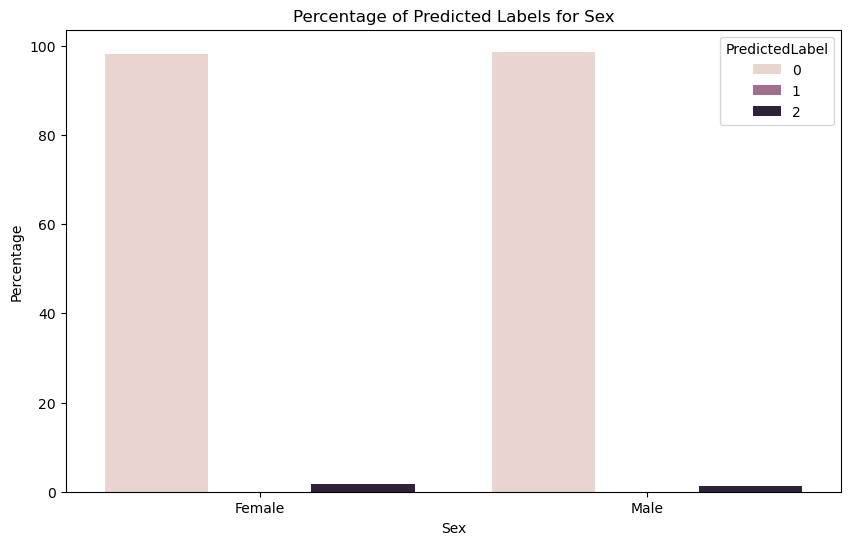

In [48]:
# Calculate the count of each predicted label for each sex
count_data = df_test.groupby(['Sex', 'PredictedLabel']).size().reset_index(name='Count')

# Calculate the total count for each sex
total_counts = df_test['Sex'].value_counts().reset_index(name='Total').rename(columns={'index': 'Sex'})

# Merge the counts and total counts
merged_data = pd.merge(count_data, total_counts, on='Sex')

# Calculate the percentage
merged_data['Percentage'] = (merged_data['Count'] / merged_data['Total']) * 100

# Plotting the percentage
plt.figure(figsize=(10, 6))
sns.barplot(data=merged_data, x='Sex', y='Percentage', hue='PredictedLabel')
plt.title('Percentage of Predicted Labels for Sex')
tick_positions = plt.gca().get_xticks()
plt.xticks(ticks=tick_positions, labels=['Female', 'Male'])
plt.ylabel('Percentage')
plt.show()

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/438562092.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df_test.groupby(['Sex', 'TrueLabel']).size().reset_index(name='Count')


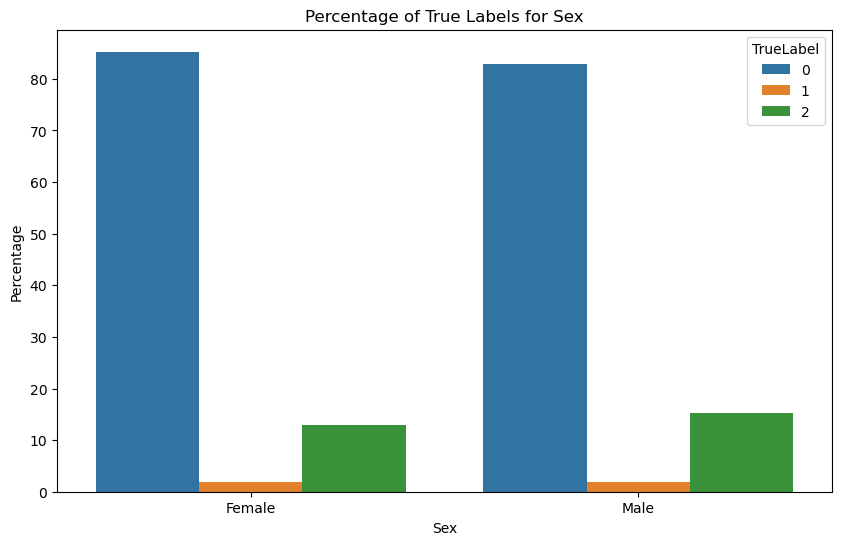

In [49]:
# Calculate the count of each true label for each sex
count_data = df_test.groupby(['Sex', 'TrueLabel']).size().reset_index(name='Count')

# Calculate the total count for each sex
total_counts = df_test['Sex'].value_counts().reset_index(name='Total').rename(columns={'index': 'Sex'})

# Merge the counts and total counts
merged_data = pd.merge(count_data, total_counts, on='Sex')

# Calculate the percentage
merged_data['Percentage'] = (merged_data['Count'] / merged_data['Total']) * 100

# Plotting the percentage
plt.figure(figsize=(10, 6))
sns.barplot(data=merged_data, x='Sex', y='Percentage', hue='TrueLabel')
plt.title('Percentage of True Labels for Sex')
tick_positions = plt.gca().get_xticks()
plt.xticks(ticks=tick_positions, labels=['Female', 'Male'])
plt.ylabel('Percentage')
plt.show()

Based on the graph showing the Percentage of Predicted Labels for Sex, females are a bit more likely to have diabetes (class 2) than male. However, in the graph, Percentage of True Labels by Sex, males are actually a bit more likely to have diabetes than female. 

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/908210053.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data_income = df_test.groupby(['Income', 'PredictedLabel']).size().reset_index(name='Count')


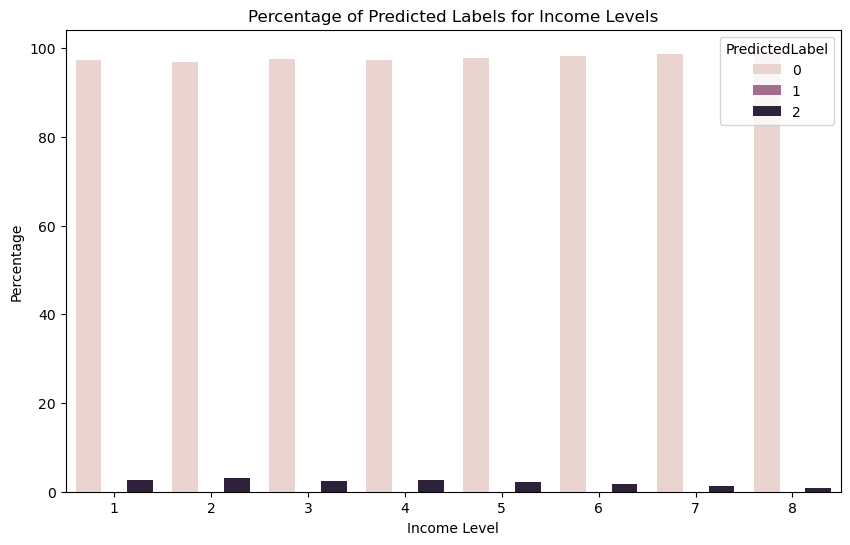

In [50]:
# Calculate the count of each predicted label for each income level
count_data_income = df_test.groupby(['Income', 'PredictedLabel']).size().reset_index(name='Count')

# Calculate the total count for each income level
total_counts_income = df_test['Income'].value_counts().reset_index(name='Total').rename(columns={'index': 'Income'})

# Merge the counts and total counts
merged_data_income = pd.merge(count_data_income, total_counts_income, on='Income')

# Calculate the percentage
merged_data_income['Percentage'] = (merged_data_income['Count'] / merged_data_income['Total']) * 100

# Plotting the percentage
plt.figure(figsize=(10, 6))
sns.barplot(data=merged_data_income, x='Income', y='Percentage', hue='PredictedLabel')
plt.title('Percentage of Predicted Labels for Income Levels')
plt.xlabel('Income Level')
plt.ylabel('Percentage')
plt.show()

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/2357674822.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df_test.groupby(['Income', 'TrueLabel']).size().reset_index(name='Count')


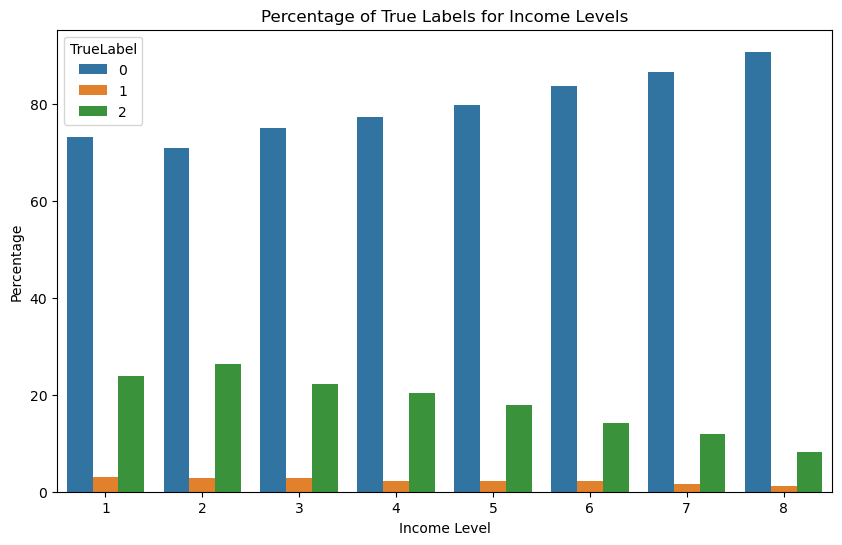

In [51]:
# Calculate the count of each true label for different income levels
count_data = df_test.groupby(['Income', 'TrueLabel']).size().reset_index(name='Count')

# Calculate the total count for different income levels
total_counts = df_test['Income'].value_counts().reset_index(name='Total').rename(columns={'index': 'Income'})

# Merge the counts and total counts
merged_data = pd.merge(count_data, total_counts, on='Income')

# Calculate the percentage
merged_data['Percentage'] = (merged_data['Count'] / merged_data['Total']) * 100

# Plotting the percentage
plt.figure(figsize=(10, 6))
sns.barplot(data=merged_data, x='Income', y='Percentage', hue='TrueLabel')
plt.title('Percentage of True Labels for Income Levels')
tick_positions = plt.gca().get_xticks()
plt.xlabel('Income Level')
plt.ylabel('Percentage')
plt.show()

Based on the graph showing the Percentage of Predicted Labels for Income Level, lower income levels are a bit more likely to have diabetes than higher income levels. However, in the graph, Percentage of True Labels for Income Levels, there is an obvious trend that people of lower income levels are more likely to have diabetes. 

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/2852359724.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data_education = df_test.groupby(['Education', 'PredictedLabel']).size().reset_index(name='Count')


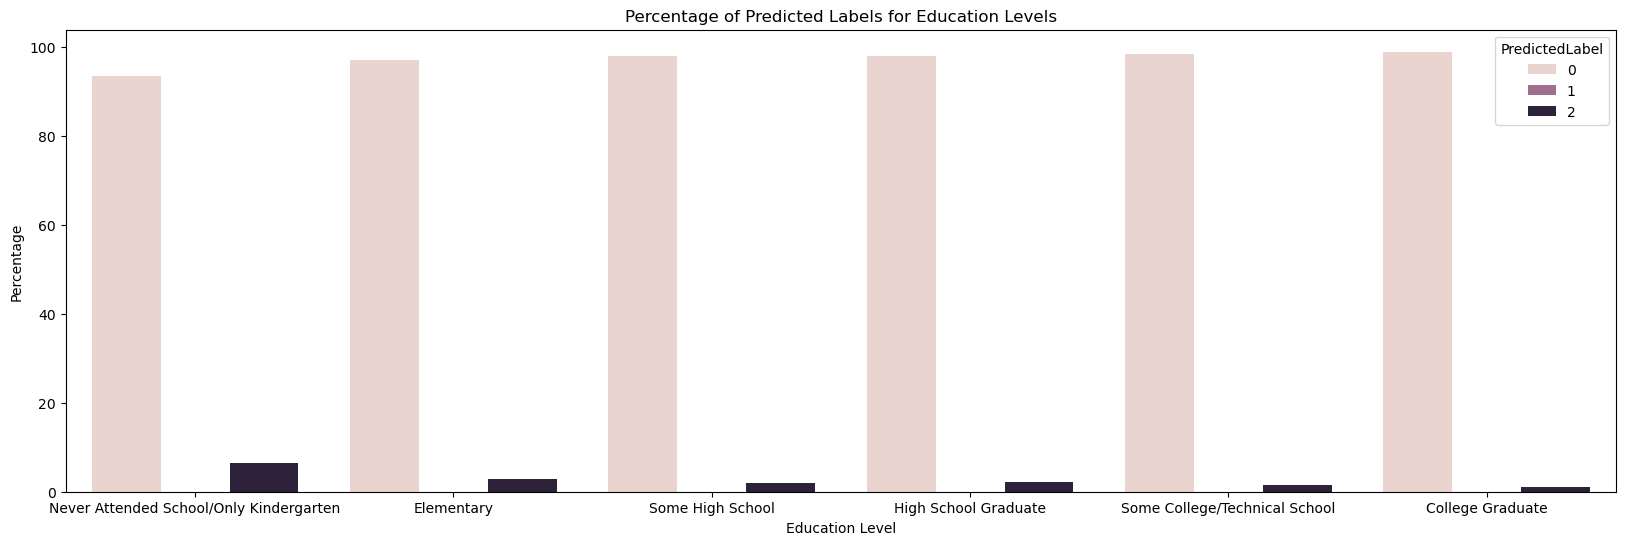

In [52]:
# Calculate the count of each predicted label for each education level
count_data_education = df_test.groupby(['Education', 'PredictedLabel']).size().reset_index(name='Count')

# Calculate the total count for each education level
total_counts_education = df_test['Education'].value_counts().reset_index(name='Total').rename(columns={'index': 'Education'})

# Merge the counts and total counts
merged_data_education = pd.merge(count_data_education, total_counts_education, on='Education')

# Calculate the percentage
merged_data_education['Percentage'] = (merged_data_education['Count'] / merged_data_education['Total']) * 100

# Plotting the percentage
plt.figure(figsize=(20, 6))
sns.barplot(data=merged_data_education, x='Education', y='Percentage', hue='PredictedLabel')
plt.title('Percentage of Predicted Labels for Education Levels')
plt.xlabel('Education Level')
plt.ylabel('Percentage')
tick_positions = plt.gca().get_xticks()
plt.xticks(ticks=tick_positions, labels=['Never Attended School/Only Kindergarten', 'Elementary', 
                                         'Some High School', 'High School Graduate', 
                                         'Some College/Technical School', 'College Graduate'])
plt.show()

/var/folders/kr/mdklt42n4jn0qzzt_q2hmvj00000gn/T/ipykernel_16222/4261233536.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df_test.groupby(['Education', 'TrueLabel']).size().reset_index(name='Count')


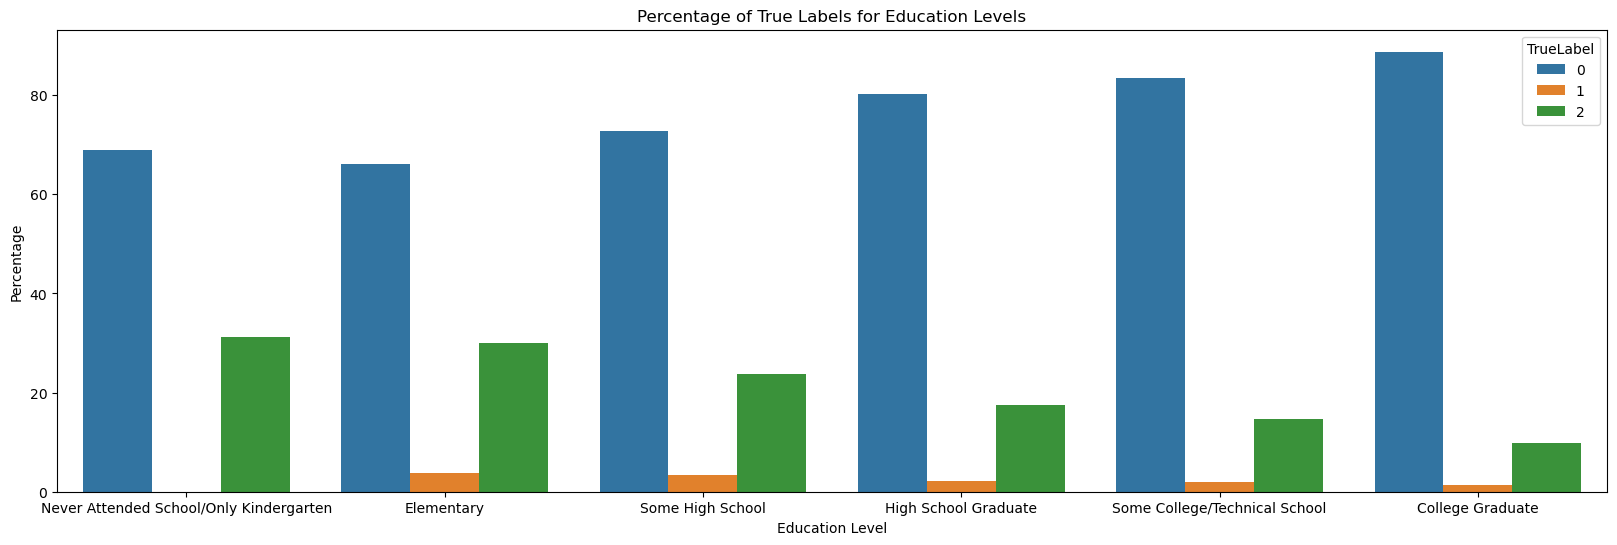

In [53]:
# Calculate the count of each true label for different education levels
count_data = df_test.groupby(['Education', 'TrueLabel']).size().reset_index(name='Count')

# Calculate the total count for different education levels
total_counts = df_test['Education'].value_counts().reset_index(name='Total').rename(columns={'index': 'Education'})

# Merge the counts and total counts
merged_data = pd.merge(count_data, total_counts, on='Education')

# Calculate the percentage
merged_data['Percentage'] = (merged_data['Count'] / merged_data['Total']) * 100

# Plotting the percentage
plt.figure(figsize=(20, 6))
sns.barplot(data=merged_data, x='Education', y='Percentage', hue='TrueLabel')
plt.title('Percentage of True Labels for Education Levels')
tick_positions = plt.gca().get_xticks()
plt.xticks(ticks=tick_positions, labels=['Never Attended School/Only Kindergarten', 'Elementary', 
                                         'Some High School', 'High School Graduate', 
                                         'Some College/Technical School', 'College Graduate'])
plt.xlabel('Education Level')
plt.ylabel('Percentage')
plt.show()

Based on the graph showing the Percentage of Predicted Labels for Education Level, lower education levels are a bit more likely to have diabetes (class 2) than higher education levels. However, in the graph, Percentage of True Labels by Education level, there is an obvious trend that people with lower education level are more likely to have diabetes. 

By comparing and contrasting these predictions for different groups, we can say that there is a bias in gender because males are more likely to be predicted as healthy even when it is not the case. Thus, to eliminate some of these biases, we can do oversampling which is increasing the representation of minority groups in the training data.